# Three-Parameter EOS & Chao-Seader — Milestone 7.3 (v0.5.0)

The two-parameter cubic EOS (PR, RKS, …) fix the critical compressibility $Z_c$ at a single family value (0.307 for PR, 0.333 for RKS), which is wrong for almost every real fluid. **Three-parameter EOS add a third constant $c$** so each component gets its own $Z_c$, improving liquid densities and polar-fluid behavior. This milestone ports the three Pascal three-parameter models — **Schmidt-Wenzel, Patel-Teja, and Patel-Teja USB** — plus the **Chao-Seader** semi-empirical liquid-fugacity correlation (with its special hydrogen and methane coefficient sets). Ref (4): Da Silva & Báez (1989).

## Setup (optional)

The cell below is **commented out by default**. Uncomment it if you want to use the latest `vle-thermo` released on PyPI instead of whatever version is currently installed in your kernel.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel.
# %pip install --upgrade vle-thermo

## Context — the third parameter

From [Chapter II §2.3](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md), a cubic EOS writes pressure as a repulsive plus an attractive term. A **two-parameter** form fixes the attractive denominator with the family constants $(k_1, k_2)$:

$$P = \frac{R T}{V - b} - \frac{a\,\alpha(T_r)}{V^2 + k_1 b V + k_2 b^2}.$$

A **three-parameter** form generalizes the denominator to $V^2 + u V + w'$, where $u$ and $w'$ encode a component-specific third constant $c$ (equivalently, a fitted critical compressibility $\xi_c$). In the engine this is handled uniformly: the same cubic and fugacity algebra is reused with the dimensionless groups $U = uP/RT$ and $W = w'(P/RT)^2$ (the two-parameter case is just $U = k_1 B,\; W = k_2 B^2$).

| EOS | third parameter | reduces $Z_c$ error via |
|---|---|---|
| Schmidt-Wenzel | $\beta(\omega)$ + acentric $c=\omega$ | $\omega$-dependent denominator |
| Patel-Teja | fitted $\xi_c(\omega)$ | $c = (1-3\xi_c)\,RT_c/P_c$ |
| Patel-Teja USB | same as PT (differs only in **mixture** $c$ rule) | $\sqrt{B}$-weighted mixing (M8) |

All three are ported from `legacy/pascal/TERMOII.PAS` (Ref (4)). The Schmidt-Wenzel $m(T_r)$ is **piecewise** — its slope is discontinuous at $T_r=1$; the engine reproduces the legacy values but uses a guarded one-sided derivative so the entropy stays finite there (the original returned NaN).

## What was built in Milestone 7.3

Through `vle._engine`:

- The three-parameter variants `CubicEos.SchmidtWenzel`, `.PatelTeja`, `.PatelTejaUSB` now flow through the **same** public functions as the two-parameter zoo: `eos_alpha`, `eos_d_alpha_d_tr`, `eos_z_factor`, `eos_ln_phi_pure`, `eos_h_departure_rt`, `eos_s_departure_r`.
- `chao_seader_ln_phi(t, p, tc, pc, omega, species)` — the Chao-Seader liquid fugacity coefficient as $\ln\nu$, with `ChaoSeaderSpecies.{Normal, Hydrogen, Methane}`.
- (Rust) `mixing::c_mix` — the $c$-parameter mixture rules, ready for the mixture work in M8.

Every new α has an **analytical** dα/dT_r (verified against a central-difference oracle in the test suite).

## Worked example

Imports and two reference components.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import vle._engine as e
%matplotlib inline

print('vle-thermo', e.version())

N_PENTANE = dict(tc=469.7, pc=3370.0, omega=0.252)   # K, kPa, –
METHANE = dict(tc=190.564, pc=4599.0, omega=0.0115)

THREE_PARAM = {
    'Schmidt-Wenzel': e.CubicEos.SchmidtWenzel,
    'Patel-Teja': e.CubicEos.PatelTeja,
    'Patel-Teja USB': e.CubicEos.PatelTejaUSB,
}

vle-thermo 0.5.0


### α(T_r): the three-parameter models vs Peng-Robinson

Every α passes through 1 at the critical point ($T_r = 1$) — the EOS-specific prefactor is folded into $\Omega_a$, so the bare α keeps the standard convention.

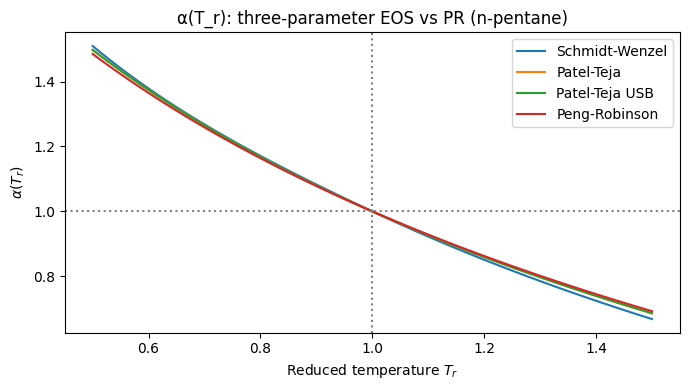

In [3]:
trs = np.linspace(0.5, 1.5, 80)
w = N_PENTANE['omega']
plt.figure(figsize=(7, 4))
for name, eos in {**THREE_PARAM, 'Peng-Robinson': e.CubicEos.PR1976}.items():
    plt.plot(trs, [e.eos_alpha(eos, tr, w) for tr in trs], label=name)
plt.axhline(1.0, ls=':', c='grey'); plt.axvline(1.0, ls=':', c='grey')
plt.xlabel(r'Reduced temperature $T_r$'); plt.ylabel(r'$\alpha(T_r)$')
plt.title('α(T_r): three-parameter EOS vs PR (n-pentane)')
plt.legend(); plt.tight_layout(); plt.show()

# α(T_r = 1) = 1 for every three-parameter model.
for eos in THREE_PARAM.values():
    assert abs(e.eos_alpha(eos, 1.0, w) - 1.0) < 1e-12

### Compressibility factor and fugacity coefficient

Vapor and liquid roots and $\ln\varphi$ for n-pentane. The three-parameter $Z_c$ differs per model, which is exactly the point — it shifts the liquid root.

In [4]:
tc, pc, w = N_PENTANE['tc'], N_PENTANE['pc'], N_PENTANE['omega']
T_vap, P_vap = 400.0, 500.0      # K, kPa (vapor)
T_liq, P_liq = 300.0, 2000.0     # K, kPa (compressed liquid)
print(f"{'EOS':<16}{'Z_vap':>9}{'Z_liq':>9}{'ln_phi_vap':>12}")
for name, eos in {**THREE_PARAM, 'Peng-Robinson': e.CubicEos.PR1976}.items():
    zv = e.eos_z_factor(eos, T_vap, P_vap, tc, pc, w, 'vapor')
    zl = e.eos_z_factor(eos, T_liq, P_liq, tc, pc, w, 'liquid')
    lnp = e.eos_ln_phi_pure(eos, T_vap, P_vap, tc, pc, w, 'vapor')
    print(f'{name:<16}{zv:>9.4f}{zl:>9.4f}{lnp:>12.4f}')

# Ideal-gas limit sanity check: Z -> 1, ln_phi -> 0 as P -> 0.
z0 = e.eos_z_factor(e.CubicEos.PatelTeja, 400.0, 1e-3, tc, pc, w, 'vapor')
assert abs(z0 - 1.0) < 1e-4

EOS                 Z_vap    Z_liq  ln_phi_vap
Schmidt-Wenzel     0.9040   0.0926     -0.0927
Patel-Teja         0.9036   0.0916     -0.0931
Patel-Teja USB     0.9036   0.0916     -0.0931
Peng-Robinson      0.9027   0.0900     -0.0940


### Chao-Seader liquid fugacity

Chao-Seader returns the liquid fugacity coefficient $\nu = f_L/(xP)$ from a regular-solution + reduced-property correlation, with **distinct coefficient sets** for hydrogen and methane (their quantum/light-gas behavior breaks the normal-fluid fit). We return $\ln\nu$ to match `eos_ln_phi_pure`.

In [5]:
cases = [
    ('n-pentane', N_PENTANE, e.ChaoSeaderSpecies.Normal),
    ('methane',   METHANE,   e.ChaoSeaderSpecies.Methane),
]
for label, comp, species in cases:
    t = 0.7 * comp['tc']          # a representative reduced temperature
    ln_nu = e.chao_seader_ln_phi(t, 500.0, comp['tc'], comp['pc'], comp['omega'], species)
    print(f'{label:<10} ({str(species).split(chr(46))[-1]:<7}) ln nu = {ln_nu:+.4f}  ->  nu = {np.exp(ln_nu):.4f}')

# Using the wrong coefficient set changes the answer materially:
t = 0.7 * METHANE['tc']
ln_methane = e.chao_seader_ln_phi(t, 500.0, METHANE['tc'], METHANE['pc'], METHANE['omega'], e.ChaoSeaderSpecies.Methane)
ln_as_normal = e.chao_seader_ln_phi(t, 500.0, METHANE['tc'], METHANE['pc'], METHANE['omega'], e.ChaoSeaderSpecies.Normal)
print(f'\nmethane: dedicated set ln nu = {ln_methane:+.4f}, normal set ln nu = {ln_as_normal:+.4f}')
assert abs(ln_methane - ln_as_normal) > 1e-3

n-pentane  (Normal ) ln nu = -1.0536  ->  nu = 0.3487
methane    (Methane) ln nu = +0.2961  ->  nu = 1.3446

methane: dedicated set ln nu = +0.2961, normal set ln nu = -0.2010


## Exercise 1 — Z vs pressure for Patel-Teja

Plot the **vapor** compressibility factor of Patel-Teja n-pentane at $T = 450$ K over $P = 10 \dots 2000$ kPa, and confirm $Z \to 1$ as $P \to 0$. Fill in the `# TODO`s.

In [6]:
tc, pc, w = N_PENTANE['tc'], N_PENTANE['pc'], N_PENTANE['omega']
pressures = np.linspace(10.0, 2000.0, 50)
# TODO: build a list `zs` of vapor Z values at T = 450 K for each P.
# zs = [e.eos_z_factor(...) for p in pressures]
# TODO: plot zs vs pressures, and assert the low-P value is ~1.


<details><summary>Solution</summary>

```python
zs = [e.eos_z_factor(e.CubicEos.PatelTeja, 450.0, p, tc, pc, w, 'vapor') for p in pressures]
plt.figure(figsize=(7, 4))
plt.plot(pressures, zs)
plt.xlabel('Pressure (kPa)'); plt.ylabel('Z (vapor)')
plt.title('Patel-Teja vapor Z — n-pentane at 450 K'); plt.tight_layout(); plt.show()
z_low = e.eos_z_factor(e.CubicEos.PatelTeja, 450.0, 1e-3, tc, pc, w, 'vapor')
assert abs(z_low - 1.0) < 1e-4
```
</details>

## Exercise 2 — Schmidt-Wenzel entropy across $T_r = 1$

The Schmidt-Wenzel α has a slope kink at $T_r = 1$. Evaluate the **entropy departure** $S^R/R$ for Schmidt-Wenzel n-pentane (vapor) at $T_r = 0.95, 1.00, 1.05$ (i.e. $T = 0.95\,T_c$, etc.) at $P = 500$ kPa and confirm every value is **finite** (the legacy returned NaN at $T_r = 1$).

In [7]:
import math
tc, pc, w = N_PENTANE['tc'], N_PENTANE['pc'], N_PENTANE['omega']
# TODO: for tr in (0.95, 1.00, 1.05), compute T = tr*tc and
#       s = e.eos_s_departure_r(e.CubicEos.SchmidtWenzel, T, 500.0, tc, pc, w, 'vapor')
#       then assert math.isfinite(s).


<details><summary>Solution</summary>

```python
for tr in (0.95, 1.00, 1.05):
    s = e.eos_s_departure_r(e.CubicEos.SchmidtWenzel, tr * tc, 500.0, tc, pc, w, 'vapor')
    print(f'Tr={tr:.2f}  S^R/R = {s:+.5f}')
    assert math.isfinite(s)
```
</details>

## References

- **(4)** Da Silva, F. A.; Báez, L. *Desarrollo de un Paquete Computacional…*, Universidad Simón Bolívar, 1989 — origin of the Schmidt-Wenzel, Patel-Teja, and Chao-Seader implementations (`legacy/pascal/TERMOII.PAS`).
- **(5)** Abbott, M. M. — generalized cubic-EOS form.
- [Chapter II §2.3](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md) — cubic EOS theory.
- [`MODERNIZATION_PLAN.md`](https://github.com/miguelju/vle/blob/main/MODERNIZATION_PLAN.md) — Phase 7 notes and the unified (U, W) three-parameter formulation.
- Two-parameter α zoo: [`02b_alpha_zoo.ipynb`](02b_alpha_zoo.ipynb). Advanced saturation models (M7.4): [`02d_advanced_saturation.ipynb`](02d_advanced_saturation.ipynb).